# 17 - Word2Vec Next Word Prediction

Goal: usar embeddings Word2Vec preentrenados como entrada de una red con softmax para predecir la siguiente palabra.

Run with: conda activate tfenv

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd
import random
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")

I0000 00:00:1779051728.739351     318 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1779051728.865024     318 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779051731.608020     318 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TensorFlow version: 2.21.0


In [2]:
# Cargar embeddings Word2Vec preentrenados
class MyWord2Vec:
    def __init__(self, path='../myWord2Vec/v1/'):
        target_embeddings = np.load(path + 'target_embeddings.npy')
        context_embeddings = np.load(path + 'context_embeddings.npy')
        text_vocab = np.load(path + 'text_vocab.npy', allow_pickle=True).item()

        self.layer = layers.Embedding(
            input_dim=target_embeddings.shape[0],
            output_dim=target_embeddings.shape[1],
            weights=[target_embeddings],
            trainable=False,
            name='pretrained_embedding'
        )
        self.target_embeddings = target_embeddings
        self.context_embeddings = context_embeddings
        self.text_vocab = text_vocab
        self.idx_to_word = {idx: word for word, idx in text_vocab.items()}
        self.final_embeddings = (target_embeddings + context_embeddings) / 2
        print('Embeddings cargados:', target_embeddings.shape, context_embeddings.shape, 'Vocabulario:', len(text_vocab))

    def encode(self, words):
        return [self.text_vocab[w] for w in words if w in self.text_vocab]

    def decode(self, token_id):
        return self.idx_to_word.get(int(token_id), '<unk>')

myWord2Vec = MyWord2Vec()

Embeddings cargados: (807, 64) (807, 64) Vocabulario: 807


E0000 00:00:1779051736.101020     318 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1779051736.127252     318 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [3]:
# Cargar texto y crear secuencias contexto -> siguiente palabra
print('Loading gaianet/london dataset...')
from datasets import load_dataset

ds = load_dataset('gaianet/london', split='train')
texts = [row['text'] if 'text' in row else row.get('content', '') for row in ds][:10000]
full_text = ' '.join(texts[:5000])

words = full_text.lower().split()
words = [w.strip('.,;:!?()[]"-0123456789') for w in words]
words = [w for w in words if len(w) > 2 and w in myWord2Vec.text_vocab]
print(f'Total words used: {len(words)}')
print(f'Sample: {words[:20]}')

def create_next_word_sequences(words, window=2):
    X, y = [], []
    for i in range(len(words) - window):
        context = words[i:i + window]
        target = words[i + window]
        if all(w in myWord2Vec.text_vocab for w in context + [target]):
            X.append([myWord2Vec.text_vocab[w] for w in context])
            y.append(myWord2Vec.text_vocab[target])
    return np.array(X, dtype=np.int32), np.array(y, dtype=np.int32)

X, y = create_next_word_sequences(words, window=2)
print(f'Sequences created: {len(X)}')
print(f'Input shape: {X.shape}, Target shape: {y.shape}')

if len(X) == 0:
    raise ValueError('No se pudieron crear secuencias con el vocabulario cargado.')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

Loading gaianet/london dataset...


/home/eanorambuena/miniconda/envs/tfenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total words used: 17777
Sample: ['london', 'the', 'capital', 'and', 'largest', 'city', 'england', 'and', 'the', 'united', 'kingdom', 'with', 'population', 'around', 'million', 'and', 'the', 'largest', 'city', 'western']
Sequences created: 17775
Input shape: (17775, 2), Target shape: (17775,)


In [4]:
# Modelo con softmax sobre todo el vocabulario
vocab_size = myWord2Vec.target_embeddings.shape[0]
embed_dim = myWord2Vec.target_embeddings.shape[1]

model = keras.Sequential([
    layers.Input(shape=(2,), dtype='int32'),
    myWord2Vec.layer,
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(vocab_size, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(min(len(X_train), 2000)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pretrained_embedding            │ (None, 2, 64)          │        51,648 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 807)            │        52,455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 112,359 (438.90 KB)

 Trainable params: 60,711 (237.15 KB)

 Non-trainable params: 51,648 (201.75 KB)

Epoch 1/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.1247 - loss: 5.7165 - val_accuracy: 0.1398 - val_loss: 5.4155
Epoch 2/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.1435 - loss: 5.0580 - val_accuracy: 0.1426 - val_loss: 5.0990
Epoch 3/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1572 - loss: 4.5926 - val_accuracy: 0.1533 - val_loss: 4.7828
Epoch 4/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.1819 - loss: 4.1320 - val_accuracy: 0.1685 - val_loss: 4.5082
Epoch 5/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2168 - loss: 3.7448 - val_accuracy: 0.1733 - val_loss: 4.3233
Epoch 6/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2498 - loss: 3.4577 - val_accuracy: 0.1913 - val_loss: 4.1969
Epoch 7/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2774 - loss: 3.2378 - val_accuracy: 0.1997 - val_loss: 4.0977
Epoch 8/10
223/223 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2978 - loss: 3.0675 - val_accuracy: 0.

Test accuracy: 0.224
Contexto ['london', 'bridge'] -> [('the', 0.15257203578948975), ('which', 0.1096869558095932), ('and', 0.08678027242422104), ("london's", 0.05861789360642433), ('both', 0.0437244288623333)]


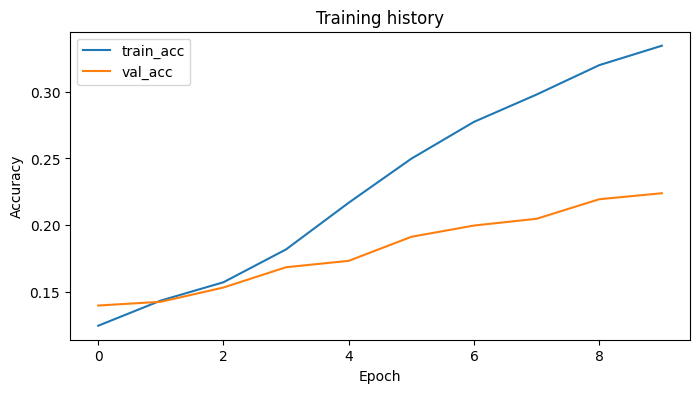

In [5]:
# Evaluación y ejemplos de predicción de siguiente palabra
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

loss, acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {acc:.3f}')

def predict_next_word(context_words, top_n=5):
    context_ids = [myWord2Vec.text_vocab[w] for w in context_words if w in myWord2Vec.text_vocab]
    if len(context_ids) < 2:
        return []
    context_ids = np.array([context_ids[:2]], dtype=np.int32)
    probs = model.predict(context_ids, verbose=0)[0]
    top_indices = np.argsort(probs)[-top_n:][::-1]
    return [(myWord2Vec.decode(idx), float(probs[idx])) for idx in top_indices]

sample_contexts = [
    ['london', 'bridge'],
    ['bank', 'of'],
    ['queen', 'of']
]

for context in sample_contexts:
    preds = predict_next_word(context, top_n=5)
    if preds:
        print(f"Contexto {context} -> {preds}")

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Training history')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()